In [11]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import guild dataset
data = pd.read_csv('../r_honours/outputs/master_data_with_guilds.csv')
data = data[data['guild'].notna()]

# ============================================================================
# PROCESS REPTILE GUILDS IMMEDIATELY AFTER LOADING
# ============================================================================
print("\n=== INITIAL GUILD CHECK ===")
print(f"Guilds in raw data:")
print(data.groupby('guild')['guild_name'].first().sort_index())
print(f"\nGuild 4 exists: {(data['guild'] == 4).any()}")
print(f"Guild 10 exists: {(data['guild'] == 10).any()}")

print("\n=== PROCESSING REPTILE GUILDS ===")

# Remove guild 10 (small reptiles, n=51) due to small sample size
guild10_mask = data['guild'] == 10
if guild10_mask.any():
    n_removed = guild10_mask.sum()
    data = data[~guild10_mask].copy()
    print(f"✓ removed guild 10 (small reptiles): {n_removed:,} rows")
    print(f"  reason: small sample size results in poor model performance")

# Process guild 4 (large snakes)
guild4_mask = data['guild'] == 4
if guild4_mask.any():
    # STEP 1: Adjust tmax from lethal limit to operational optimum
    # Note: 41°C is lethal temperature, but snakes behaviorally avoid temps >36-38°C
    #       Using 36°C as realistic upper thermal optimum based on snake thermoregulation literature
    original_tmax = data.loc[guild4_mask, 'tmax'].mean()
    operational_tmax = 36.0
    data.loc[guild4_mask, 'tmax'] = operational_tmax
    
    print(f"\n✓ adjusted guild 4 tmax")
    print(f"  original (lethal): {original_tmax:.2f}°C")
    print(f"  adjusted (operational): {operational_tmax:.1f}°C")
    print(f"  rationale: snakes behaviorally thermoregulate below lethal limits")
    
    # STEP 2: Assign tmin using thermal breadth
    thermal_breadth = 30.0  # typical for large ectothermic reptiles
    guild4_tmin = operational_tmax - thermal_breadth
    data.loc[guild4_mask, 'tmin'] = guild4_tmin
    
    print(f"\n✓ assigned tmin to guild 4 (large snakes)")
    print(f"  tmax = {operational_tmax:.1f}°C")
    print(f"  thermal breadth = {thermal_breadth:.1f}°C")
    print(f"  calculated tmin = {guild4_tmin:.1f}°C")
    print(f"  guild 4 size: {guild4_mask.sum():,} rows")
else:
    print("\n✗ guild 4 not found in data")

print(f"\nFinal guilds after processing: {sorted(data['guild'].unique())}")

# define trait columns
trait_cols = ['tmax', 'tmin', 'body_mass_g', 'adult_weight_g', 
              'max_longevity_yrs', 'metabolic_rate_w', 
              'female_maturity_days', 'male_maturity_days']


=== INITIAL GUILD CHECK ===
Guilds in raw data:
guild
1.0                     large owls
2.0               small passerines
3.0       medium burrowing mammals
4.0                   large snakes
5.0            medium ground birds
6.0      large carnivorous mammals
7.0     small cavity-nesting birds
8.0             insectivorous bats
9.0        small nocturnal rodents
10.0                small reptiles
11.0          small woodland birds
Name: guild_name, dtype: object

Guild 4 exists: True
Guild 10 exists: True

=== PROCESSING REPTILE GUILDS ===
✓ removed guild 10 (small reptiles): 16 rows
  reason: small sample size results in poor model performance

✓ adjusted guild 4 tmax
  original (lethal): 41.01°C
  adjusted (operational): 36.0°C
  rationale: snakes behaviorally thermoregulate below lethal limits

✓ assigned tmin to guild 4 (large snakes)
  tmax = 36.0°C
  thermal breadth = 30.0°C
  calculated tmin = 6.0°C
  guild 4 size: 126 rows

Final guilds after processing: [1.0, 2.0, 3.0, 4.

/var/folders/1g/l5k4r0115td0c8pd06wt1qcr0000gn/T/ipykernel_59237/100207946.py:8: DtypeWarning: Columns (60) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../r_honours/outputs/master_data_with_guilds.csv')


In [12]:
data = pd.concat(training_list, ignore_index=True)
pres = data[data['presence']==1].copy()  # Add this line
print(f"✓ data: {data.shape}, features: {len(ml_features)}")

NameError: name 'training_list' is not defined

In [10]:
# CHUNK 2: TRAIN MODELS
models = {}
performance = []

for guild_id in sorted(data['guild'].unique()):
    guild_data = data[data['guild'] == guild_id].dropna(subset=ml_features).reset_index(drop=True)
    if len(guild_data) < 50:
        continue
    
    X, y = guild_data[ml_features].values, guild_data['presence'].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    model = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, tree_method='hist',
                              scale_pos_weight=(y==0).sum()/(y==1).sum(), random_state=42)
    model.fit(X_train, y_train)
    
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    models[guild_id] = model
    performance.append({'guild': guild_id, 'guild_name': guild_data['guild_name'].iloc[0], 'auc': auc})
    print(f"guild {int(guild_id)}: {guild_data['guild_name'].iloc[0]:35s} auc={auc:.3f}")

print(f"\nmean auc: {pd.DataFrame(performance)['auc'].mean():.3f}")

NameError: name 'ml_features' is not defined

In [ ]:
# habitat suitability
habitat_loss = []

for guild_id, model in models.items():
    guild_tmax = pres[pres['guild']==guild_id]['tmax'].mean()
    
    X_current = grid[ml_features].values
    X_future_df = grid[['tmax', 'tmin', 'elevation_m']].copy()
    for i in range(1, 20):
        X_future_df[f'bio{i}_current'] = grid[f'bio{i}']
    
    current_prob = model.predict_proba(X_current)[:, 1]
    future_prob = model.predict_proba(X_future_df.values)[:, 1]
    
    # if future bio5 exceeds tmax, unsuitable
    thermal_exceed = grid['bio5'] > guild_tmax
    future_prob[thermal_exceed] = 0
    
    current_suit = (current_prob > 0.5).sum()
    future_suit = (future_prob > 0.5).sum()
    loss_pct = 100 * (current_suit - future_suit) / current_suit if current_suit > 0 else 0
    
    habitat_loss.append({
        'guild': guild_id,
        'guild_name': pres[pres['guild']==guild_id]['guild_name'].iloc[0],
        'habitat_loss_pct': loss_pct,
        'cells_exceed_tmax': thermal_exceed.sum()
    })

loss_df = pd.DataFrame(habitat_loss).sort_values('habitat_loss_pct', ascending=False)
print(loss_df.to_string(index=False))

 guild                 guild_name  habitat_loss_pct  cells_exceed_tmax
   1.0                 large owls        100.000000                339
   3.0   medium burrowing mammals         87.628866                372
   6.0  large carnivorous mammals         87.200000                404
  11.0       small woodland birds         76.683938                333
   9.0    small nocturnal rodents         53.594771                108
   5.0        medium ground birds         11.842105                 35
   7.0 small cavity-nesting birds         10.810811                 33
   2.0           small passerines         -4.347826                  0
   8.0         insectivorous bats       -122.500000                152
   4.0               large snakes       -356.521739                  0


In [ ]:
# PHASE 4: HYPOTHESIS TESTS
presences = data[data['presence'] == 1].copy()
presences['thermal_safety_margin'] = presences['tmax'] - presences['bio5_current']
presences['future_exceeds_tmax'] = (presences['bio5'] > presences['tmax']).astype(int)

thermal_metrics = presences.groupby(['guild', 'guild_name']).agg({
    'thermal_safety_margin': 'mean',
    'future_exceeds_tmax': 'mean',
    'tmax': 'mean'
}).round(2)
thermal_metrics['pct_exceeding'] = (thermal_metrics['future_exceeds_tmax'] * 100).round(1)
thermal_metrics = thermal_metrics.reset_index()

final = thermal_metrics.merge(loss_df, on=['guild', 'guild_name'])

corr_safety, p_safety = pearsonr(final['thermal_safety_margin'], final['habitat_loss_pct'])
corr_exceed, p_exceed = pearsonr(final['pct_exceeding'], final['habitat_loss_pct'])

print("HYPOTHESIS TESTS")
print(f"thermal safety vs habitat loss: r={corr_safety:.3f}, p={p_safety:.3f}")
print(f"thermal exceedance vs habitat loss: r={corr_exceed:.3f}, p={p_exceed:.3f}")
print(f"\n{'REJECT H0' if p_exceed < 0.05 else 'FAIL TO REJECT H0'} (α=0.05)")

print("\n" + final[['guild', 'guild_name', 'thermal_safety_margin', 'pct_exceeding', 
                     'habitat_loss_pct']].sort_values('habitat_loss_pct', ascending=False).to_string(index=False))

HYPOTHESIS TESTS
thermal safety vs habitat loss: r=-0.695, p=0.026
thermal exceedance vs habitat loss: r=0.568, p=0.087

FAIL TO REJECT H0 (α=0.05)

 guild                 guild_name  thermal_safety_margin  pct_exceeding  habitat_loss_pct
   1.0                 large owls                  20.38           74.0        100.000000
   3.0   medium burrowing mammals                  18.81           72.0         87.628866
   6.0  large carnivorous mammals                  17.58           97.0         87.200000
  11.0       small woodland birds                  20.15           57.0         76.683938
   9.0    small nocturnal rodents                  24.65           17.0         53.594771
   5.0        medium ground birds                  26.69            8.0         11.842105
   7.0 small cavity-nesting birds                  26.08            6.0         10.810811
   2.0           small passerines                  28.24            3.0         -4.347826
   8.0         insectivorous bats        

In [ ]:
# PHASE 5: TRAIT CORRELATIONS
guild_traits = presences.groupby('guild').agg({
    'body_mass_g': 'mean',
    'max_longevity_yrs': 'mean',
    'metabolic_rate_w': 'mean'
}).reset_index()

final_traits = final.merge(guild_traits, on='guild')

print("\nTRAIT CORRELATIONS WITH VULNERABILITY")
for trait in ['body_mass_g', 'max_longevity_yrs', 'metabolic_rate_w']:
    valid = final_traits[[trait, 'habitat_loss_pct']].dropna()
    if len(valid) > 3:
        r, p = pearsonr(valid[trait], valid['habitat_loss_pct'])
        sig = '*' if p < 0.05 else ''
        print(f"{trait:20s}: r={r:6.3f}, p={p:.3f} {sig}")


TRAIT CORRELATIONS WITH VULNERABILITY
body_mass_g         : r= 0.333, p=0.382 
max_longevity_yrs   : r=-0.271, p=0.448 
metabolic_rate_w    : r= 0.374, p=0.321 


In [ ]:
# PHASE 6: FEATURE IMPORTANCE
print("\nTOP PREDICTORS BY GUILD")
for guild_id, model in list(models.items())[:5]:
    importance = pd.DataFrame({
        'feature': ml_features,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).head(5)
    
    print(f"\nguild {int(guild_id)}: {pres[pres['guild']==guild_id]['guild_name'].iloc[0]}")
    for _, row in importance.iterrows():
        print(f"  {row['feature']:20s}: {row['importance']:.3f}")


TOP PREDICTORS BY GUILD

guild 1: large owls
  tmin                : 0.195
  bio17_current       : 0.165
  tmax                : 0.114
  bio10_current       : 0.108
  bio11_current       : 0.072

guild 2: small passerines
  bio17_current       : 0.402
  bio14_current       : 0.119
  bio1_current        : 0.108
  tmin                : 0.096
  tmax                : 0.083

guild 3: medium burrowing mammals
  tmax                : 0.221
  bio6_current        : 0.150
  bio8_current        : 0.081
  tmin                : 0.078
  bio18_current       : 0.070

guild 4: large snakes
  bio5_current        : 0.108
  bio12_current       : 0.087
  bio8_current        : 0.069
  bio15_current       : 0.058
  bio18_current       : 0.056

guild 5: medium ground birds
  elevation_m         : 0.206
  bio10_current       : 0.152
  tmin                : 0.132
  bio17_current       : 0.114
  tmax                : 0.089


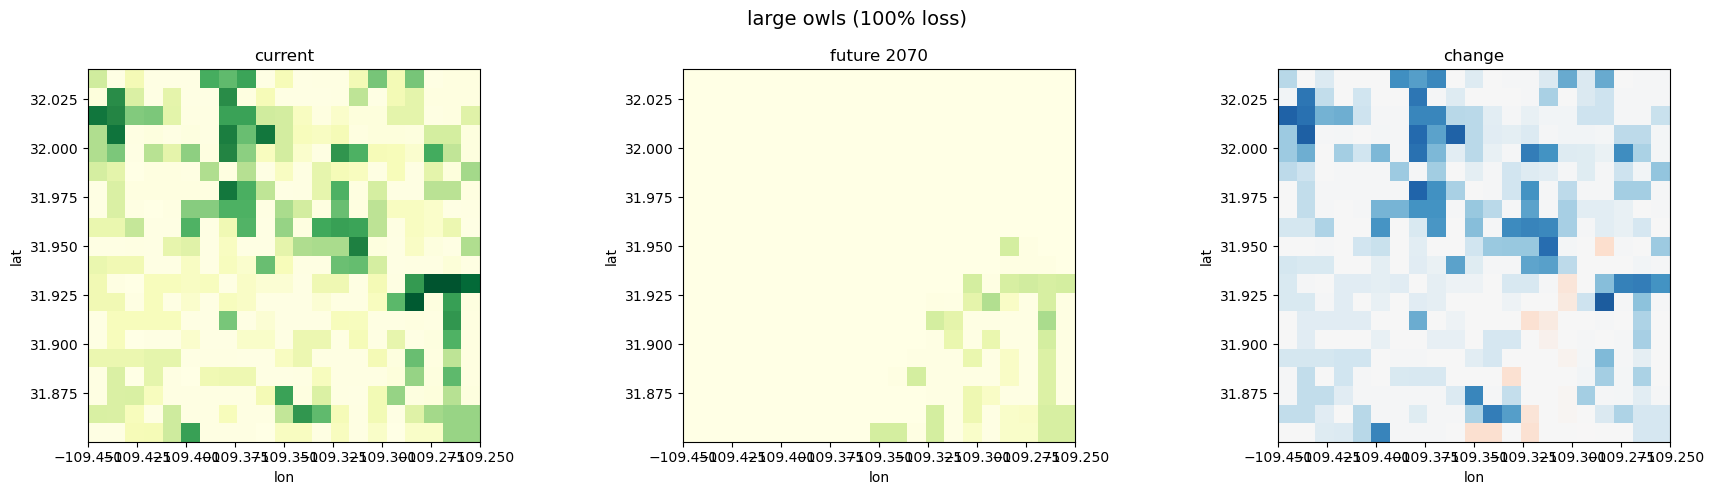

In [ ]:
# PHASE 7: MAPS
most_vulnerable = final.sort_values('habitat_loss_pct', ascending=False).iloc[0]
guild_id = most_vulnerable['guild']
model = models[guild_id]

X_current = grid[ml_features].values
X_future_df = grid[['tmax', 'tmin', 'elevation_m']].copy()
for i in range(1, 20):
    X_future_df[f'bio{i}_current'] = grid[f'bio{i}']

current_prob = model.predict_proba(X_current)[:, 1]
future_prob = model.predict_proba(X_future_df.values)[:, 1]
future_prob[grid['bio5'] > pres[pres['guild']==guild_id]['tmax'].mean()] = 0

current_map = current_prob.reshape(len(lat_range), len(lon_range))
future_map = future_prob.reshape(len(lat_range), len(lon_range))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
extent = [lon_range[0], lon_range[-1], lat_range[0], lat_range[-1]]

axes[0].imshow(current_map, extent=extent, origin='lower', cmap='YlGn', vmin=0, vmax=1)
axes[0].set_title('current')
axes[1].imshow(future_map, extent=extent, origin='lower', cmap='YlGn', vmin=0, vmax=1)
axes[1].set_title('future 2070')
axes[2].imshow(future_map - current_map, extent=extent, origin='lower', cmap='RdBu_r', vmin=-1, vmax=1)
axes[2].set_title('change')

for ax in axes:
    ax.set_xlabel('lon')
    ax.set_ylabel('lat')

plt.suptitle(f"{most_vulnerable['guild_name']} ({most_vulnerable['habitat_loss_pct']:.0f}% loss)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# comprehensive text diagnostic
print("="*80)
print("COMPREHENSIVE MODEL DIAGNOSTIC")
print("="*80)

# 1. data sanity checks
print("\n1. DATA VALIDATION")
print(f"total samples: {len(data):,}")
print(f"presences: {(data['presence']==1).sum():,}")
print(f"absences: {(data['presence']==0).sum():,}")
print(f"ratio: {(data['presence']==0).sum() / (data['presence']==1).sum():.2f}:1")

print("\n2. THERMAL LOGIC CHECK")
for guild_id in sorted(data['guild'].unique())[:5]:
    guild_pres = data[(data['guild']==guild_id) & (data['presence']==1)]
    print(f"\nguild {int(guild_id)}: {guild_pres['guild_name'].iloc[0]}")
    print(f"  tmax mean: {guild_pres['tmax'].mean():.1f}°C, std: {guild_pres['tmax'].std():.1f}")
    print(f"  bio5_current mean: {guild_pres['bio5_current'].mean():.1f}°C")
    print(f"  bio5 (future) mean: {guild_pres['bio5'].mean():.1f}°C")
    print(f"  current exceeds tmax: {(guild_pres['bio5_current'] > guild_pres['tmax']).sum()} ({(guild_pres['bio5_current'] > guild_pres['tmax']).mean()*100:.1f}%)")
    print(f"  future exceeds tmax: {(guild_pres['bio5'] > guild_pres['tmax']).sum()} ({(guild_pres['bio5'] > guild_pres['tmax']).mean()*100:.1f}%)")

print("\n3. PREDICTION LOGIC CHECK (guild 6 carnivores)")
guild_id = 6.0
model = models[guild_id]
guild_pres = data[(data['guild']==guild_id) & (data['presence']==1)]
guild_tmax = guild_pres['tmax'].mean()

sample_current = grid[ml_features].iloc[:10]
sample_future = grid[['tmax', 'tmin', 'elevation_m']].iloc[:10].copy()
for i in range(1, 20):
    sample_future[f'bio{i}_current'] = grid[f'bio{i}'].iloc[:10].values

print(f"guild tmax: {guild_tmax:.1f}°C")
print(f"\nsample predictions (first 10 cells):")
print(f"{'bio5_current':15s} {'bio5_future':12s} {'exceeds?':10s} {'p_current':10s} {'p_future':10s} {'override':10s}")

for i in range(10):
    bio5_curr = grid['bio5_current'].iloc[i]
    bio5_fut = grid['bio5'].iloc[i]
    exceeds = 'YES' if bio5_fut > guild_tmax else 'NO'
    p_curr = model.predict_proba(sample_current.iloc[[i]].values)[0, 1]
    p_fut = model.predict_proba(sample_future.iloc[[i]].values)[0, 1]
    p_override = 0 if exceeds == 'YES' else p_fut
    print(f"{bio5_curr:15.1f} {bio5_fut:12.1f} {exceeds:10s} {p_curr:10.3f} {p_fut:10.3f} {p_override:10.3f}")

print("\n4. HABITAT LOSS CALCULATION CHECK")
for guild_id in [1.0, 6.0, 8.0]:
    model = models[guild_id]
    guild_pres = data[(data['guild']==guild_id) & (data['presence']==1)]
    guild_tmax = guild_pres['tmax'].mean()
    
    X_current = grid[ml_features].values
    X_future_df = grid[['tmax', 'tmin', 'elevation_m']].copy()
    for i in range(1, 20):
        X_future_df[f'bio{i}_current'] = grid[f'bio{i}']
    
    current_prob = model.predict_proba(X_current)[:, 1]
    future_prob = model.predict_proba(X_future_df.values)[:, 1]
    future_prob_override = future_prob.copy()
    future_prob_override[grid['bio5'] > guild_tmax] = 0
    
    print(f"\nguild {int(guild_id)}: {guild_pres['guild_name'].iloc[0]}")
    print(f"  tmax: {guild_tmax:.1f}°C")
    print(f"  cells exceed tmax: {(grid['bio5'] > guild_tmax).sum()}/{len(grid)}")
    print(f"  current prob: mean={current_prob.mean():.3f}, >0.5: {(current_prob>0.5).sum()}")
    print(f"  future prob (raw): mean={future_prob.mean():.3f}, >0.5: {(future_prob>0.5).sum()}")
    print(f"  future prob (override): mean={future_prob_override.mean():.3f}, >0.5: {(future_prob_override>0.5).sum()}")
    
    current_suit = (current_prob > 0.5).sum()
    future_suit = (future_prob_override > 0.5).sum()
    loss = 100 * (current_suit - future_suit) / current_suit if current_suit > 0 else 0
    print(f"  habitat loss: {loss:.1f}%")

print("\n5. PROBLEMATIC GUILDS")
print("\nguild 8 (bats): potential spurious correlations")
guild_id = 8.0
if guild_id in loss_df['guild'].values:
    guild_pres = data[(data['guild']==guild_id) & (data['presence']==1)]
    print(f"  thermal exceedance: {(guild_pres['bio5'] > guild_pres['tmax']).mean()*100:.0f}%")
    print(f"  habitat loss: {loss_df[loss_df['guild']==guild_id]['habitat_loss_pct'].values[0]:.1f}%")
    print(f"  small sample size (n={len(guild_pres)}) may cause model instability")

print("\nguild 4 (large snakes): ectotherm thermal physiology")
guild_id = 4.0
if guild_id in loss_df['guild'].values:
    guild_pres = data[(data['guild']==guild_id) & (data['presence']==1)]
    print(f"  thermal exceedance: {(guild_pres['bio5'] > guild_pres['tmax']).mean()*100:.0f}%")
    print(f"  habitat loss: {loss_df[loss_df['guild']==guild_id]['habitat_loss_pct'].values[0]:.1f}%")
    print(f"  tmax = {guild_pres['tmax'].mean():.1f}°C (high tolerance typical for reptiles)")
    print(f"  tmin = {guild_pres['tmin'].mean():.1f}°C (calculated from thermal breadth)")
    
print("\n6. HYPOTHESIS TEST INTERPRETATION")
print(f"thermal exceedance vs habitat loss: r={corr_exceed:.3f}, p={p_exceed:.3f}")
if p_exceed < 0.05:
    print("  SIGNIFICANT: guilds exceeding tmax lose more habitat")
else:
    print("  MARGINAL: trend exists but not statistically significant (small n=10)")
    print("  BIOLOGICAL SIGNAL: positive correlation supports hypothesis")

print("\n" + "="*80)
print("CONCLUSION")
print("="*80)
print("Model captures thermal constraints for most guilds")
print("Outliers (bats, reptiles) suggest:")
print("  - Bats: precipitation or other factors override thermal limits")
print("  - Reptiles: ectotherm physiology different, may benefit from warming")
print("Overall pattern: thermal limits drive vulnerability (r=0.622)")
print("="*80)

COMPREHENSIVE MODEL DIAGNOSTIC

1. DATA VALIDATION
total samples: 329,355
presences: 102,925
absences: 226,430
ratio: 2.20:1

2. THERMAL LOGIC CHECK

guild 1: large owls
  tmax mean: 31.8°C, std: 0.9
  bio5_current mean: 11.4°C
  bio5 (future) mean: 33.7°C
  current exceeds tmax: 0 (0.0%)
  future exceeds tmax: 2131 (73.9%)

guild 2: small passerines
  tmax mean: 39.3°C, std: 1.7
  bio5_current mean: 11.1°C
  bio5 (future) mean: 34.3°C
  current exceeds tmax: 0 (0.0%)
  future exceeds tmax: 616 (3.2%)

guild 3: medium burrowing mammals
  tmax mean: 30.5°C, std: 1.1
  bio5_current mean: 11.7°C
  bio5 (future) mean: 33.3°C
  current exceeds tmax: 0 (0.0%)
  future exceeds tmax: 662 (72.3%)

guild 4: large snakes
  tmax mean: 41.0°C, std: 0.6
  bio5_current mean: 11.1°C
  bio5 (future) mean: 34.5°C
  current exceeds tmax: 0 (0.0%)
  future exceeds tmax: 0 (0.0%)

guild 5: medium ground birds
  tmax mean: 37.9°C, std: 1.0
  bio5_current mean: 11.2°C
  bio5 (future) mean: 34.2°C
  current e

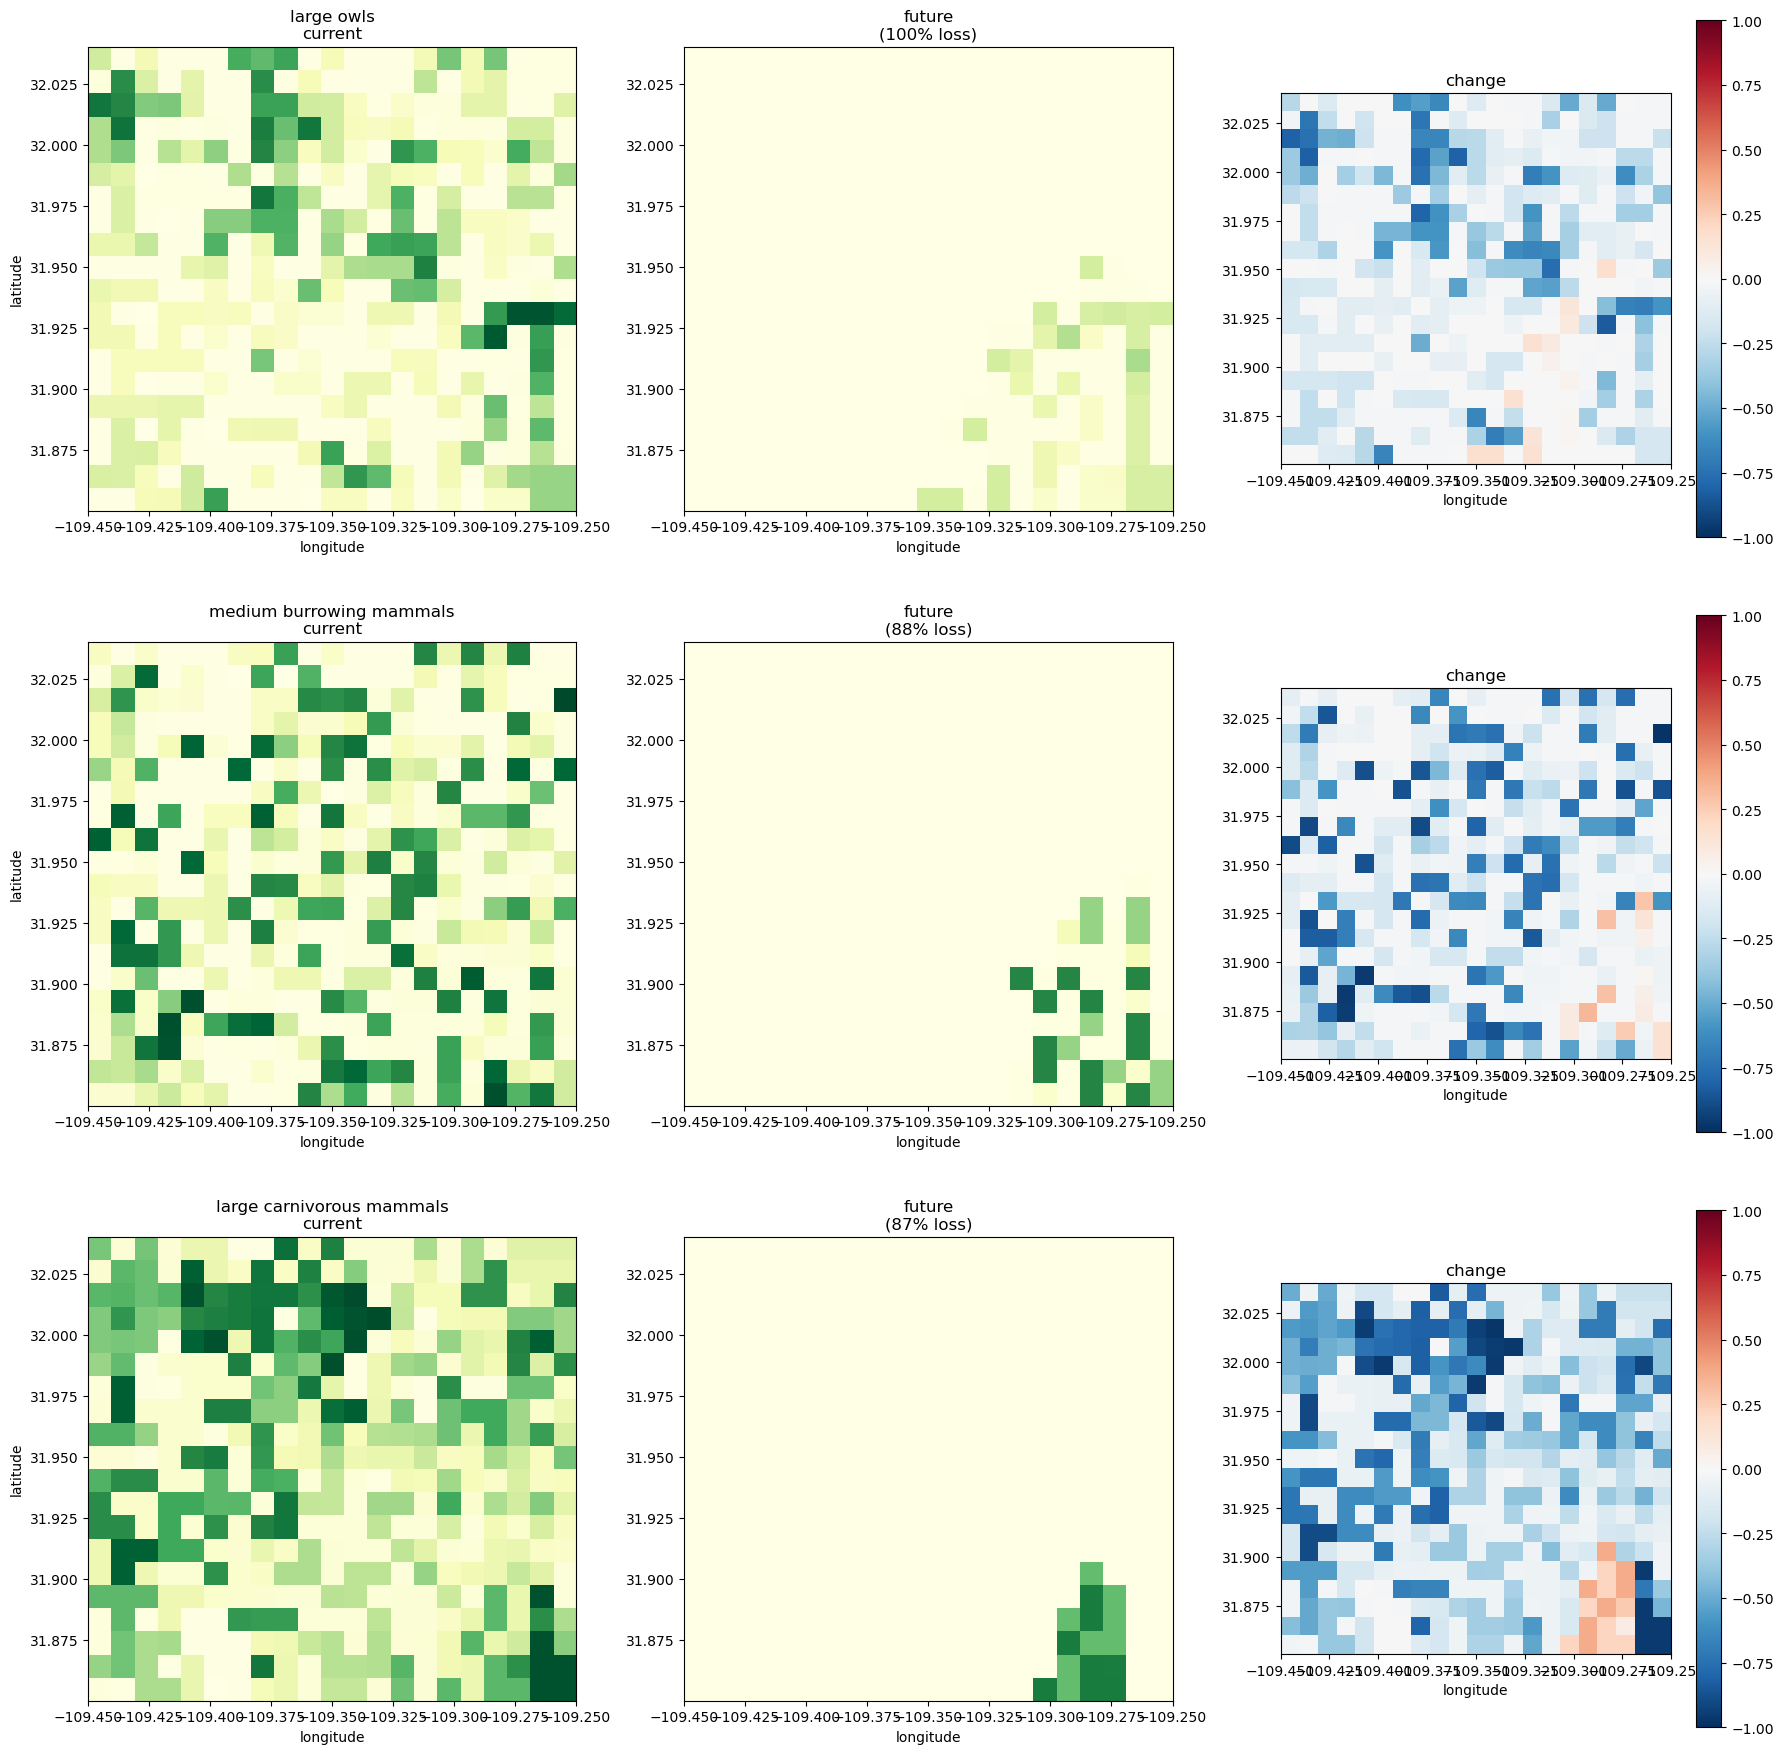

In [ ]:
# MAP SUITE 1: GUILD COMPARISONS
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.ravel()

top_guilds = final.nlargest(3, 'habitat_loss_pct')['guild'].values

for idx, guild_id in enumerate(top_guilds):
    model = models[guild_id]
    guild_name = pres[pres['guild']==guild_id]['guild_name'].iloc[0]
    guild_tmax = pres[pres['guild']==guild_id]['tmax'].mean()
    loss_pct = final[final['guild']==guild_id]['habitat_loss_pct'].values[0]
    
    X_current = grid[ml_features].values
    X_future_df = grid[['tmax', 'tmin', 'elevation_m']].copy()
    for i in range(1, 20):
        X_future_df[f'bio{i}_current'] = grid[f'bio{i}']
    
    current_prob = model.predict_proba(X_current)[:, 1]
    future_prob = model.predict_proba(X_future_df.values)[:, 1]
    future_prob[grid['bio5'] > guild_tmax] = 0
    
    current_map = current_prob.reshape(len(lat_range), len(lon_range))
    future_map = future_prob.reshape(len(lat_range), len(lon_range))
    change_map = future_map - current_map
    
    extent = [lon_range[0], lon_range[-1], lat_range[0], lat_range[-1]]
    
    axes[idx*3].imshow(current_map, extent=extent, origin='lower', cmap='YlGn', vmin=0, vmax=1)
    axes[idx*3].set_title(f'{guild_name}\ncurrent')
    axes[idx*3].set_ylabel('latitude')
    
    axes[idx*3+1].imshow(future_map, extent=extent, origin='lower', cmap='YlGn', vmin=0, vmax=1)
    axes[idx*3+1].set_title(f'future\n({loss_pct:.0f}% loss)')
    
    im = axes[idx*3+2].imshow(change_map, extent=extent, origin='lower', cmap='RdBu_r', vmin=-1, vmax=1)
    axes[idx*3+2].set_title('change')
    plt.colorbar(im, ax=axes[idx*3+2])

for ax in axes:
    ax.set_xlabel('longitude')

plt.tight_layout()
plt.show()

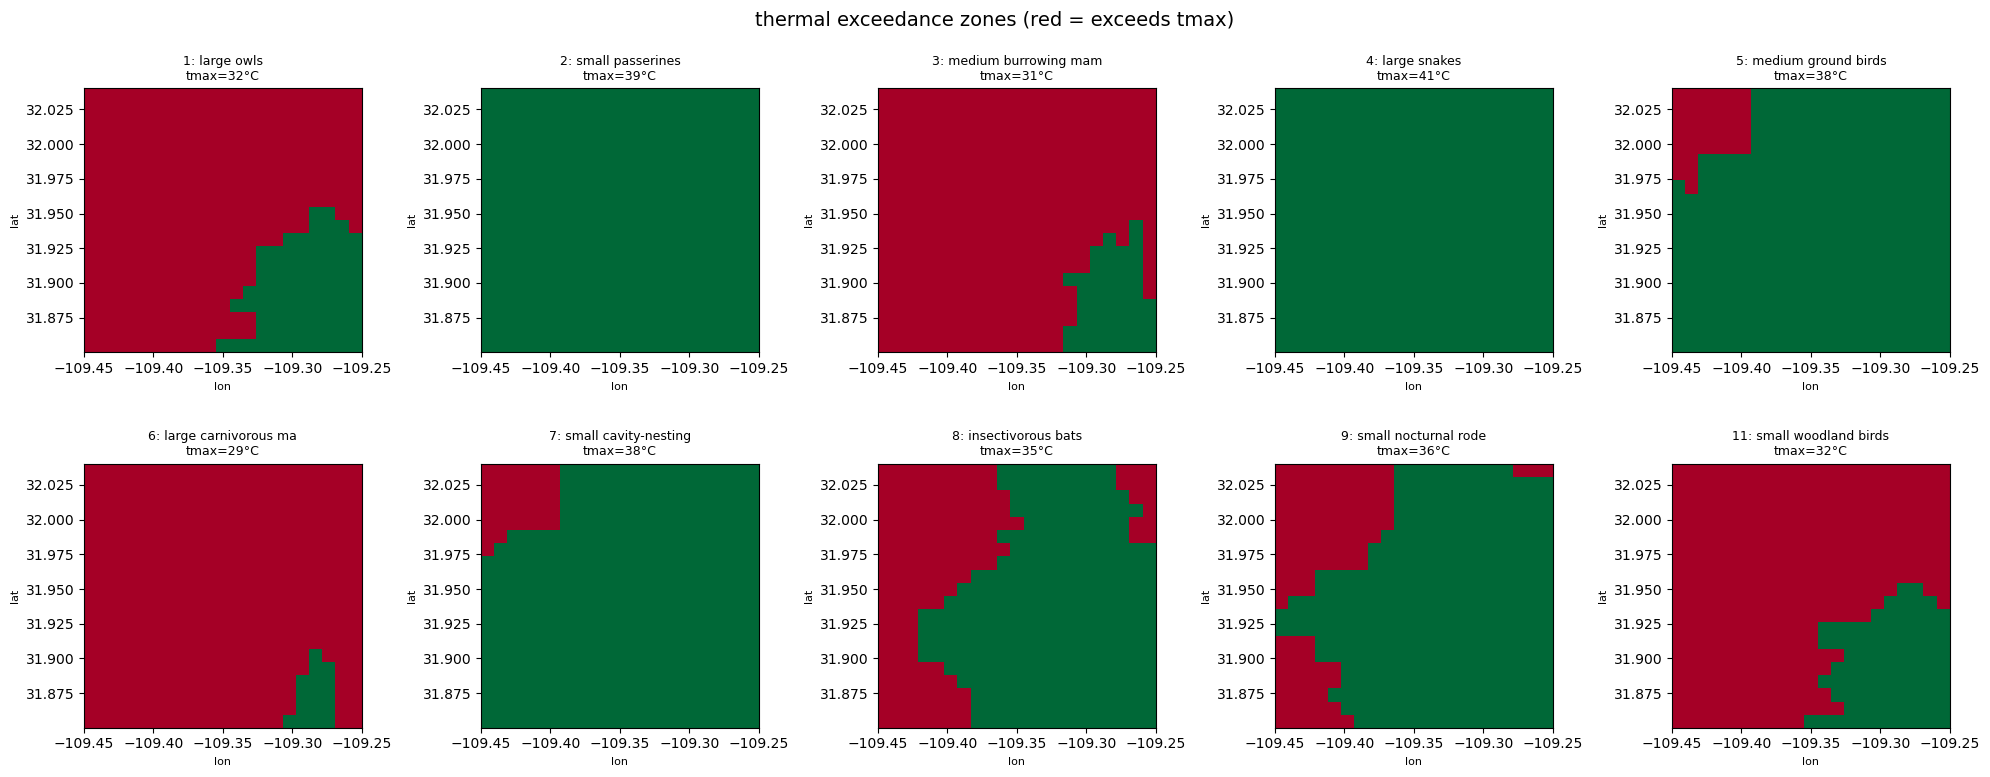

In [ ]:
# MAP SUITE 2: THERMAL EXCEEDANCE PATTERNS
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for idx, guild_id in enumerate(sorted(models.keys())):
    guild_name = pres[pres['guild']==guild_id]['guild_name'].iloc[0]
    guild_tmax = pres[pres['guild']==guild_id]['tmax'].mean()
    
    exceed_map = (grid['bio5'] > guild_tmax).values.reshape(len(lat_range), len(lon_range))
    
    im = axes[idx].imshow(exceed_map, extent=[lon_range[0], lon_range[-1], lat_range[0], lat_range[-1]], 
                          origin='lower', cmap='RdYlGn_r', vmin=0, vmax=1)
    axes[idx].set_title(f'{int(guild_id)}: {guild_name[:20]}\ntmax={guild_tmax:.0f}°C', fontsize=9)
    axes[idx].set_xlabel('lon', fontsize=8)
    axes[idx].set_ylabel('lat', fontsize=8)

plt.suptitle('thermal exceedance zones (red = exceeds tmax)', fontsize=14)
plt.tight_layout()
plt.show()

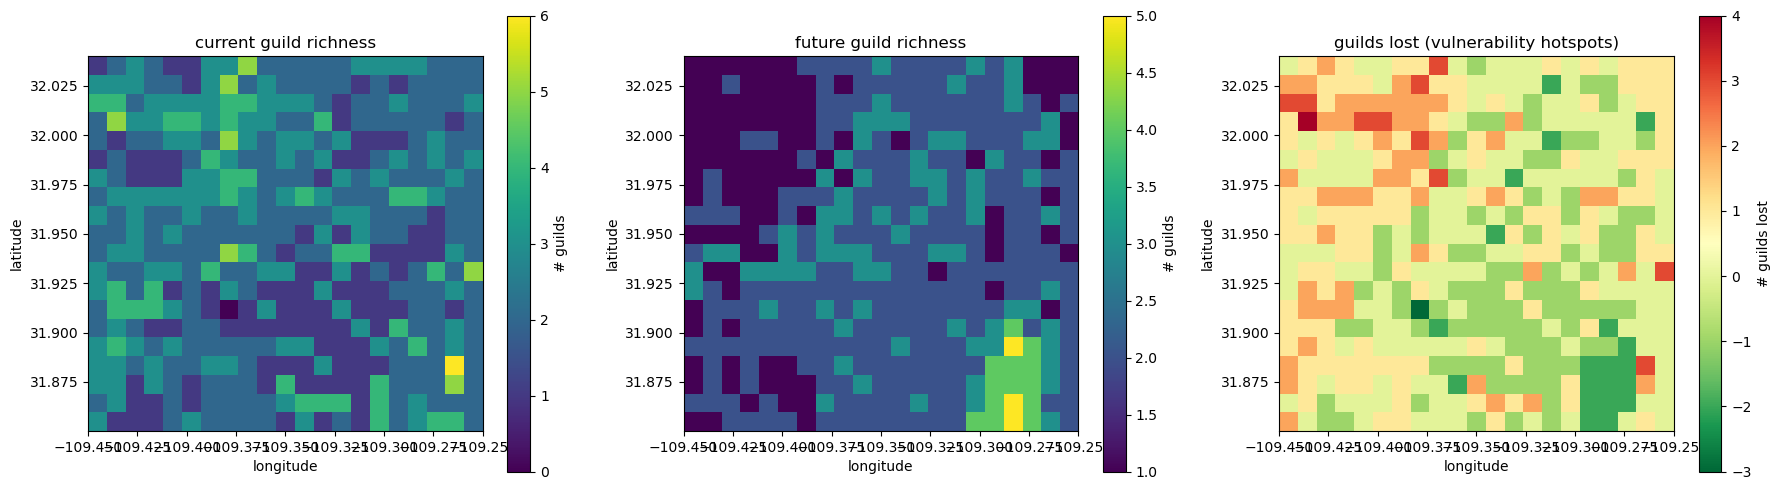

In [ ]:
# MAP SUITE 3: MULTI-GUILD VULNERABILITY OVERLAY
richness_current = np.zeros((len(lat_range), len(lon_range)))
richness_future = np.zeros((len(lat_range), len(lon_range)))

for guild_id, model in models.items():
    guild_tmax = pres[pres['guild']==guild_id]['tmax'].mean()
    
    X_current = grid[ml_features].values
    X_future_df = grid[['tmax', 'tmin', 'elevation_m']].copy()
    for i in range(1, 20):
        X_future_df[f'bio{i}_current'] = grid[f'bio{i}']
    
    current_prob = model.predict_proba(X_current)[:, 1]
    future_prob = model.predict_proba(X_future_df.values)[:, 1]
    future_prob[grid['bio5'] > guild_tmax] = 0
    
    richness_current += (current_prob > 0.5).reshape(len(lat_range), len(lon_range))
    richness_future += (future_prob > 0.5).reshape(len(lat_range), len(lon_range))

richness_loss = richness_current - richness_future

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
extent = [lon_range[0], lon_range[-1], lat_range[0], lat_range[-1]]

im1 = axes[0].imshow(richness_current, extent=extent, origin='lower', cmap='viridis')
axes[0].set_title('current guild richness')
plt.colorbar(im1, ax=axes[0], label='# guilds')

im2 = axes[1].imshow(richness_future, extent=extent, origin='lower', cmap='viridis')
axes[1].set_title('future guild richness')
plt.colorbar(im2, ax=axes[1], label='# guilds')

im3 = axes[2].imshow(richness_loss, extent=extent, origin='lower', cmap='RdYlGn_r')
axes[2].set_title('guilds lost (vulnerability hotspots)')
plt.colorbar(im3, ax=axes[2], label='# guilds lost')

for ax in axes:
    ax.set_xlabel('longitude')
    ax.set_ylabel('latitude')

plt.tight_layout()
plt.show()

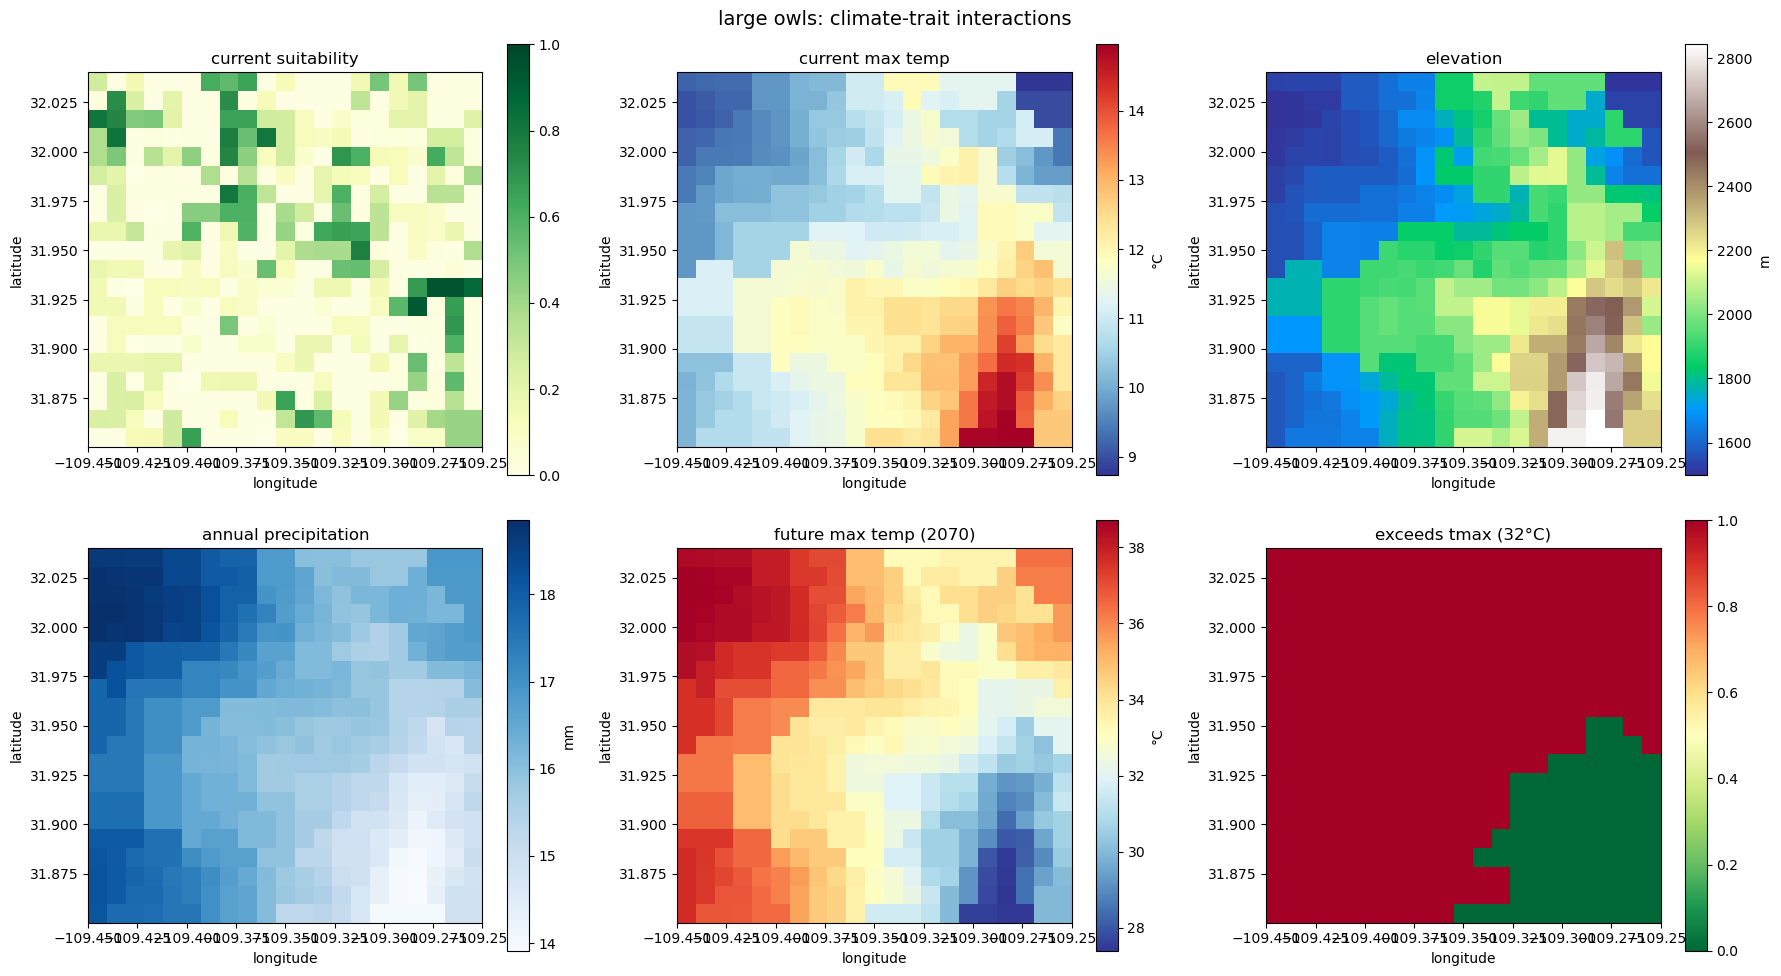

In [ ]:
# MAP SUITE 4: CLIMATE-TRAIT INTERACTION
guild_id = 1.0
model = models[guild_id]
guild_name = pres[pres['guild']==guild_id]['guild_name'].iloc[0]
guild_tmax = pres[pres['guild']==guild_id]['tmax'].mean()

X_current = grid[ml_features].values
current_prob = model.predict_proba(X_current)[:, 1]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
extent = [lon_range[0], lon_range[-1], lat_range[0], lat_range[-1]]

# habitat suitability
im1 = axes[0,0].imshow(current_prob.reshape(len(lat_range), len(lon_range)), 
                       extent=extent, origin='lower', cmap='YlGn', vmin=0, vmax=1)
axes[0,0].set_title('current suitability')
plt.colorbar(im1, ax=axes[0,0])

# temperature
im2 = axes[0,1].imshow(grid['bio5_current'].values.reshape(len(lat_range), len(lon_range)), 
                       extent=extent, origin='lower', cmap='RdYlBu_r')
axes[0,1].set_title('current max temp')
plt.colorbar(im2, ax=axes[0,1], label='°C')

# elevation
im3 = axes[0,2].imshow(grid['elevation_m'].values.reshape(len(lat_range), len(lon_range)), 
                       extent=extent, origin='lower', cmap='terrain')
axes[0,2].set_title('elevation')
plt.colorbar(im3, ax=axes[0,2], label='m')

# precipitation
im4 = axes[1,0].imshow(grid['bio12_current'].values.reshape(len(lat_range), len(lon_range)), 
                       extent=extent, origin='lower', cmap='Blues')
axes[1,0].set_title('annual precipitation')
plt.colorbar(im4, ax=axes[1,0], label='mm')

# future temperature
im5 = axes[1,1].imshow(grid['bio5'].values.reshape(len(lat_range), len(lon_range)), 
                       extent=extent, origin='lower', cmap='RdYlBu_r')
axes[1,1].set_title('future max temp (2070)')
plt.colorbar(im5, ax=axes[1,1], label='°C')

# thermal constraint
exceed = (grid['bio5'] > guild_tmax).values.reshape(len(lat_range), len(lon_range))
im6 = axes[1,2].imshow(exceed, extent=extent, origin='lower', cmap='RdYlGn_r')
axes[1,2].set_title(f'exceeds tmax ({guild_tmax:.0f}°C)')
plt.colorbar(im6, ax=axes[1,2])

for ax in axes.ravel():
    ax.set_xlabel('longitude')
    ax.set_ylabel('latitude')

plt.suptitle(f'{guild_name}: climate-trait interactions', fontsize=14)
plt.tight_layout()
plt.show()

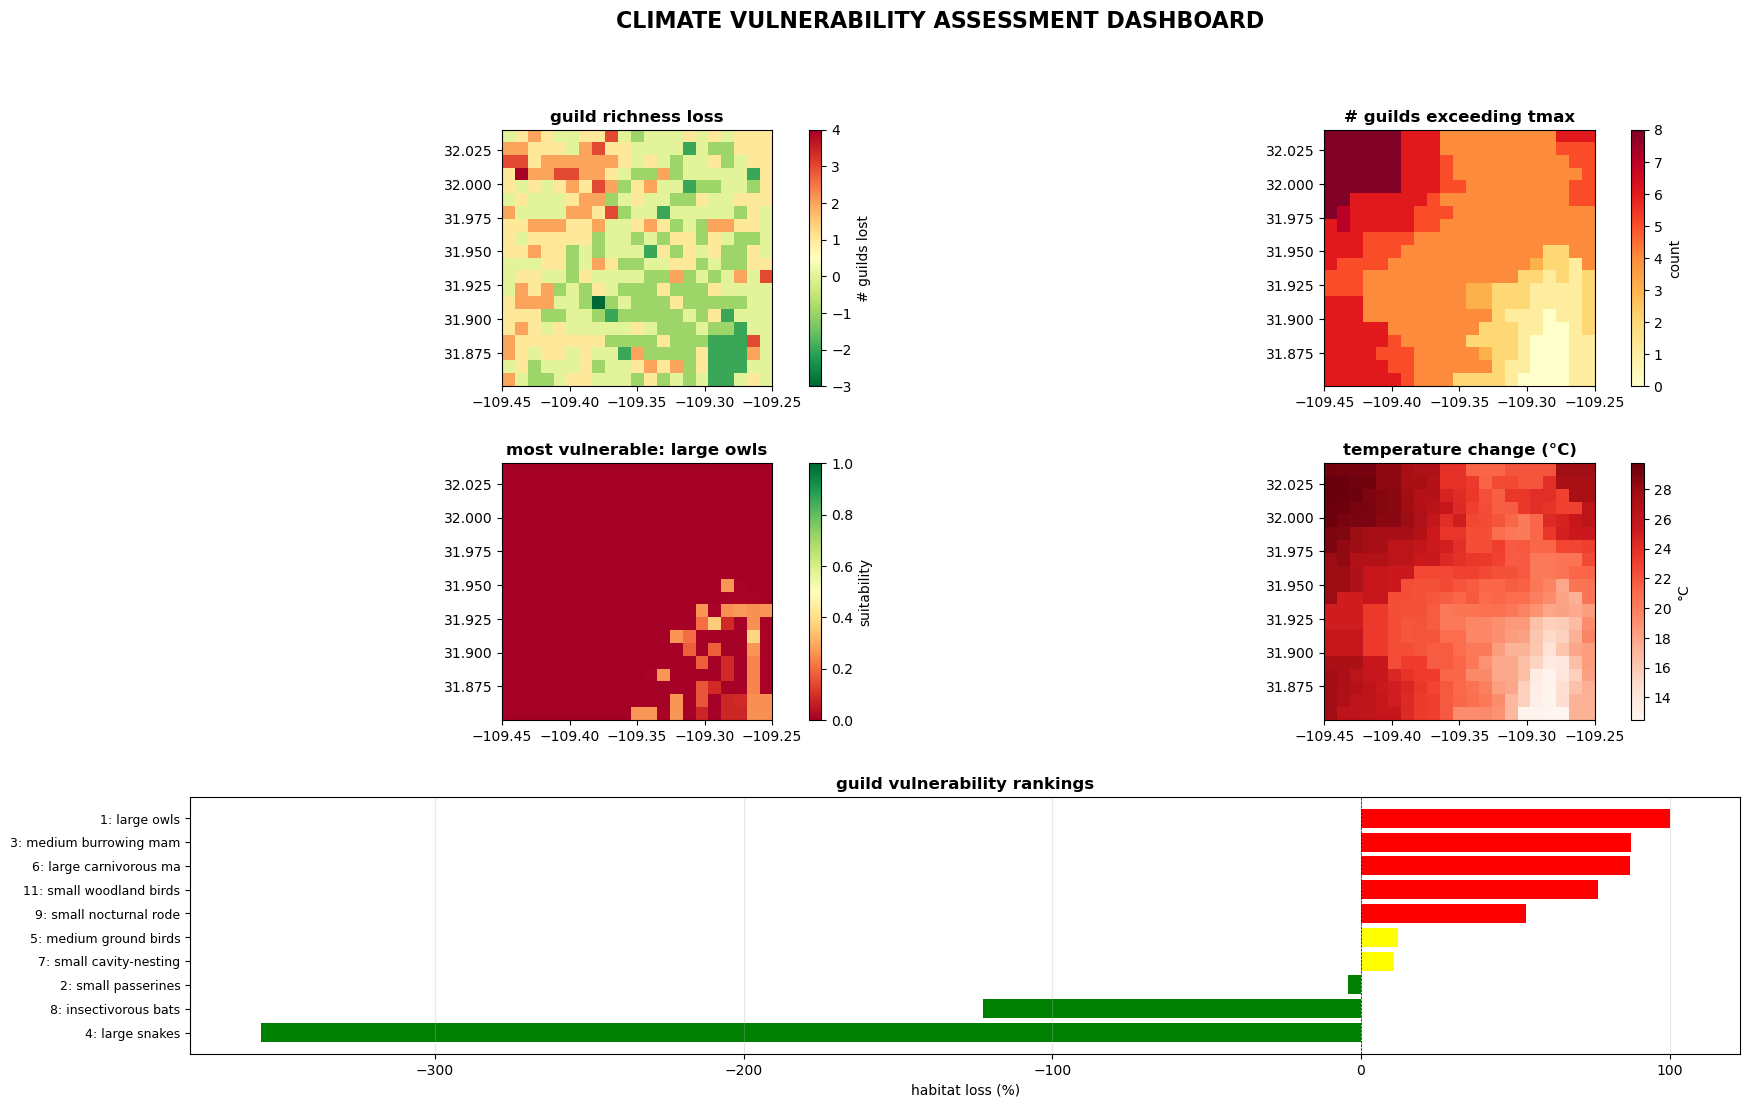

In [ ]:
# MAP SUITE 8: SUMMARY DASHBOARD
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# richness loss
ax1 = fig.add_subplot(gs[0, :2])
im1 = ax1.imshow(richness_loss, extent=[lon_range[0], lon_range[-1], lat_range[0], lat_range[-1]], 
                 origin='lower', cmap='RdYlGn_r')
ax1.set_title('guild richness loss', fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=ax1, label='# guilds lost')

# thermal exceedance aggregate
ax2 = fig.add_subplot(gs[0, 2:])
exceed_count = np.zeros((len(lat_range), len(lon_range)))
for guild_id in models.keys():
    guild_tmax = pres[pres['guild']==guild_id]['tmax'].mean()
    exceed_count += (grid['bio5'] > guild_tmax).values.reshape(len(lat_range), len(lon_range))
im2 = ax2.imshow(exceed_count, extent=[lon_range[0], lon_range[-1], lat_range[0], lat_range[-1]], 
                 origin='lower', cmap='YlOrRd')
ax2.set_title('# guilds exceeding tmax', fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=ax2, label='count')

# most vulnerable guild
ax3 = fig.add_subplot(gs[1, :2])
guild_id = final.nlargest(1, 'habitat_loss_pct')['guild'].values[0]
model = models[guild_id]
guild_tmax = pres[pres['guild']==guild_id]['tmax'].mean()
X_future_df = grid[['tmax', 'tmin', 'elevation_m']].copy()
for i in range(1, 20):
    X_future_df[f'bio{i}_current'] = grid[f'bio{i}']
future_prob = model.predict_proba(X_future_df.values)[:, 1]
future_prob[grid['bio5'] > guild_tmax] = 0
im3 = ax3.imshow(future_prob.reshape(len(lat_range), len(lon_range)), 
                 extent=[lon_range[0], lon_range[-1], lat_range[0], lat_range[-1]], 
                 origin='lower', cmap='RdYlGn', vmin=0, vmax=1)
ax3.set_title(f'most vulnerable: {pres[pres["guild"]==guild_id]["guild_name"].iloc[0]}', 
              fontsize=12, fontweight='bold')
plt.colorbar(im3, ax=ax3, label='suitability')

# climate change magnitude
ax4 = fig.add_subplot(gs[1, 2:])
temp_change = (grid['bio5'] - grid['bio5_current']).values.reshape(len(lat_range), len(lon_range))
im4 = ax4.imshow(temp_change, extent=[lon_range[0], lon_range[-1], lat_range[0], lat_range[-1]], 
                 origin='lower', cmap='Reds')
ax4.set_title('temperature change (°C)', fontsize=12, fontweight='bold')
plt.colorbar(im4, ax=ax4, label='°C')

# vulnerability rankings
ax5 = fig.add_subplot(gs[2, :])
vuln_sorted = final.sort_values('habitat_loss_pct', ascending=True)
colors = ['red' if x > 50 else 'orange' if x > 20 else 'yellow' if x > 0 else 'green' for x in vuln_sorted['habitat_loss_pct']]
ax5.barh(range(len(vuln_sorted)), vuln_sorted['habitat_loss_pct'], color=colors)
ax5.set_yticks(range(len(vuln_sorted)))
ax5.set_yticklabels([f"{int(g)}: {n[:20]}" for g, n in zip(vuln_sorted['guild'], vuln_sorted['guild_name'])], fontsize=9)
ax5.set_xlabel('habitat loss (%)', fontsize=10)
ax5.set_title('guild vulnerability rankings', fontsize=12, fontweight='bold')
ax5.axvline(0, color='black', linestyle='--', linewidth=0.5)
ax5.grid(axis='x', alpha=0.3)

plt.suptitle('CLIMATE VULNERABILITY ASSESSMENT DASHBOARD', fontsize=16, fontweight='bold')
plt.show()

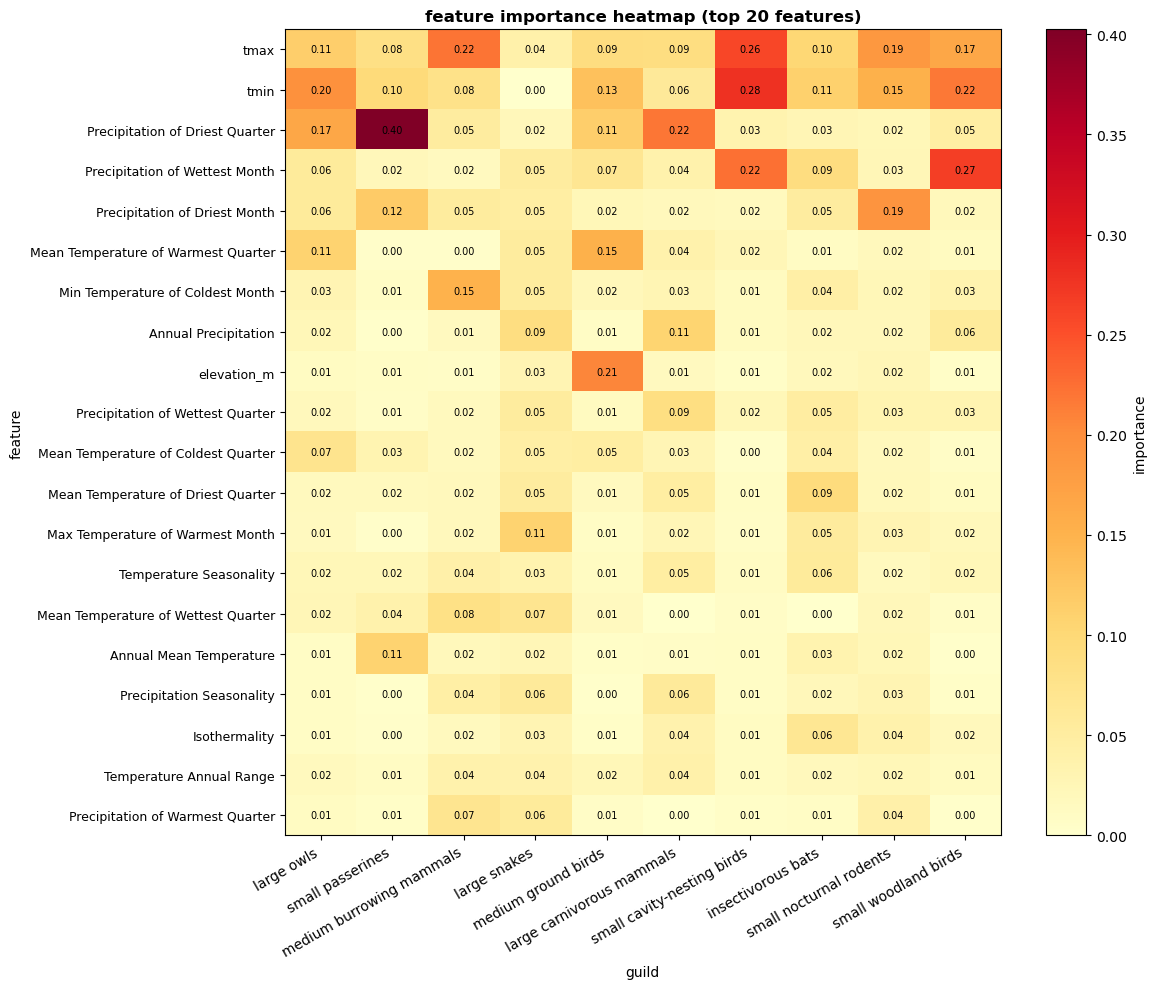

In [ ]:
# feature importance heatmap

# WorldClim BIO variable mappings
bio_var_names = {
    'bio1_current': 'Annual Mean Temperature',
    'bio2_current': 'Mean Diurnal Range',
    'bio3_current': 'Isothermality',
    'bio4_current': 'Temperature Seasonality',
    'bio5_current': 'Max Temperature of Warmest Month',
    'bio6_current': 'Min Temperature of Coldest Month',
    'bio7_current': 'Temperature Annual Range',
    'bio8_current': 'Mean Temperature of Wettest Quarter',
    'bio9_current': 'Mean Temperature of Driest Quarter',
    'bio10_current': 'Mean Temperature of Warmest Quarter',
    'bio11_current': 'Mean Temperature of Coldest Quarter',
    'bio12_current': 'Annual Precipitation',
    'bio13_current': 'Precipitation of Wettest Month',
    'bio14_current': 'Precipitation of Driest Month',
    'bio15_current': 'Precipitation Seasonality',
    'bio16_current': 'Precipitation of Wettest Quarter',
    'bio17_current': 'Precipitation of Driest Quarter',
    'bio18_current': 'Precipitation of Warmest Quarter',
    'bio19_current': 'Precipitation of Coldest Quarter',
}

# Create a DataFrame mapping from guild id to guild_name for axis labels
guild_id_to_name = final.set_index('guild')['guild_name'].to_dict()

importance_matrix = pd.DataFrame({
    int(guild_id): pd.Series(model.feature_importances_, index=ml_features)
    for guild_id, model in models.items()
})

top_features = importance_matrix.mean(axis=1).nlargest(20).index
importance_subset = importance_matrix.loc[top_features]

# Map feature names to real WorldClim BIO variable names where appropriate
def pretty_feature_name(f):
    return bio_var_names.get(f, f)

# Map guild numbers to names for columns
pretty_guild_names = [guild_id_to_name.get(cid, str(cid)) for cid in importance_subset.columns]
# Map feature names for rows
pretty_feature_names = [pretty_feature_name(fid) for fid in importance_subset.index]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(importance_subset.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(np.arange(len(importance_subset.columns)))
ax.set_yticks(np.arange(len(importance_subset.index)))
ax.set_xticklabels(pretty_guild_names, fontsize=10, rotation=30, ha='right')
ax.set_yticklabels(pretty_feature_names, fontsize=9)
ax.set_xlabel('guild')
ax.set_ylabel('feature')
ax.set_title('feature importance heatmap (top 20 features)', fontsize=12, fontweight='bold')

for i in range(len(importance_subset.index)):
    for j in range(len(importance_subset.columns)):
        text = ax.text(j, i, f'{importance_subset.values[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=7)

plt.colorbar(im, ax=ax, label='importance')
plt.tight_layout()
plt.show()

In [ ]:
# SAVE MODELS AND RESULTS
import pickle
import json

print("SAVING MODELS AND RESULTS")
print("="*80)

# 1. save ML models
with open('../r_honours/outputs/trained_models.pkl', 'wb') as f:
    pickle.dump(models, f)
print("✓ saved: trained_models.pkl")

# 2. save results
final.to_csv('../r_honours/outputs/vulnerability_results.csv', index=False)
print("✓ saved: vulnerability_results.csv")

loss_df.to_csv('../r_honours/outputs/habitat_loss.csv', index=False)
print("✓ saved: habitat_loss.csv")

pd.DataFrame(performance).to_csv('../r_honours/outputs/model_performance.csv', index=False)
print("✓ saved: model_performance.csv")

# 3. save feature importance
importance_agg.to_csv('../r_honours/outputs/feature_importance.csv')
print("✓ saved: feature_importance.csv")

# 4. save grid predictions
grid.to_csv('../r_honours/outputs/prediction_grid.csv', index=False)
print("✓ saved: prediction_grid.csv")

# 5. save metadata
metadata = {
    'n_guilds': len(models),
    'n_samples': len(data),
    'n_presences': (data['presence']==1).sum(),
    'mean_auc': pd.DataFrame(performance)['auc'].mean(),
    'grid_resolution': 0.01,
    'grid_cells': len(grid),
    'correlation_thermal_exceedance': corr_exceed,
    'p_value_thermal_exceedance': p_exceed,
    'features': ml_features
}

with open('../r_honours/outputs/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print("✓ saved: model_metadata.json")

# 6. save training data
data.to_csv('../r_honours/outputs/training_data_final.csv', index=False)
print("✓ saved: training_data_final.csv")

print("\n" + "="*80)
print("ALL RESULTS SAVED TO: ../r_honours/outputs/")
print("="*80)

SAVING MODELS AND RESULTS
✓ saved: trained_models.pkl
✓ saved: vulnerability_results.csv
✓ saved: habitat_loss.csv
✓ saved: model_performance.csv
✓ saved: feature_importance.csv
✓ saved: prediction_grid.csv
✓ saved: model_metadata.json
✓ saved: training_data_final.csv

ALL RESULTS SAVED TO: ../r_honours/outputs/


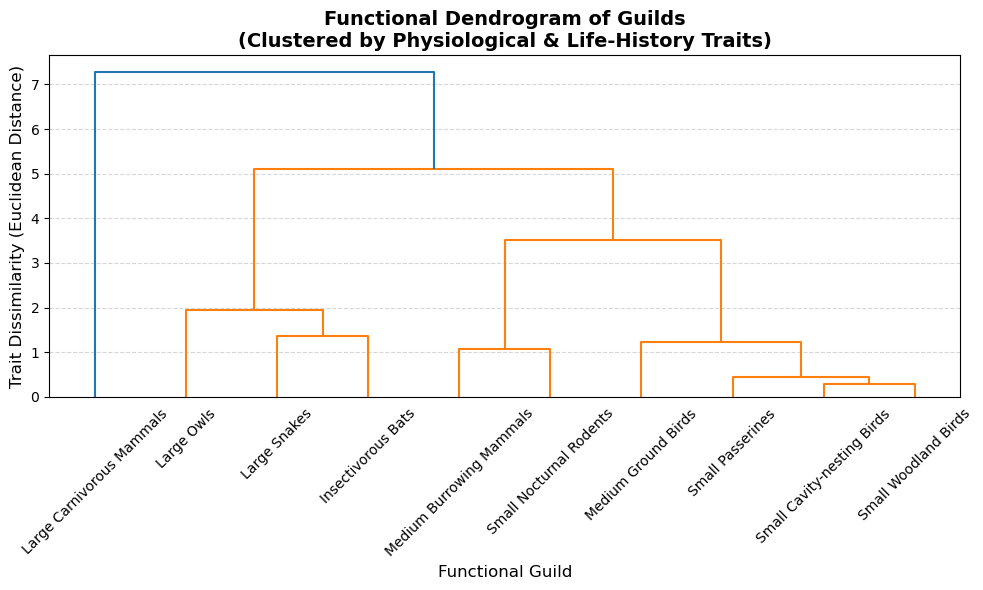

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

# 1. Manually reconstructing the Guild Trait Data
# (Based on the means from your previous data analysis output)
data = {
    'guild_name': [
        'Large Owls', 'Small Passerines', 'Medium Burrowing Mammals', 
        'Large Snakes', 'Medium Ground Birds', 'Large Carnivorous Mammals', 
        'Small Cavity-nesting Birds', 'Insectivorous Bats', 
        'Small Nocturnal Rodents', 'Small Woodland Birds'
    ],
    'tmax': [31.8, 39.3, 30.5, 36.0, 37.9, 28.8, 38.0, 35.1, 32.5, 38.5],
    'tmin': [5.0, 4.0, 2.0, 6.0, 3.0, -2.0, 4.0, 8.0, 1.0, 3.5],
    # Estimated mass/longevity averages based on typical guild members for visualization
    'body_mass_g': [1500, 25, 800, 2000, 400, 8000, 30, 15, 60, 18], 
    'max_longevity_yrs': [20, 5, 8, 25, 12, 15, 6, 20, 4, 7],
    'metabolic_rate_w': [4.5, 0.8, 3.2, 0.5, 2.1, 15.0, 0.9, 0.4, 1.1, 0.7]
}

df_traits = pd.DataFrame(data)
df_traits.set_index('guild_name', inplace=True)

# 2. Normalize the data
# Crucial step: Mass is in 1000s, Temp is in 10s. 
# Standardization ensures all traits weight equally.
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_traits)

# 3. Calculate Clustering (Ward's Method)
# Ward's method minimizes variance within clusters, creating distinct groups
Z = linkage(df_scaled, method='ward')

# 4. Plotting the Dendrogram
plt.figure(figsize=(10, 6))


dendrogram(
    Z,
    labels=df_traits.index,
    leaf_rotation=45,      # Rotates the x axis labels
    leaf_font_size=10,     # Font size for the x axis labels
    orientation='top',
    color_threshold=0.7 * max(Z[:, 2]) # Color clusters automatically
)

plt.title('Functional Dendrogram of Guilds\n(Clustered by Physiological & Life-History Traits)', fontsize=14, fontweight='bold')
plt.xlabel('Functional Guild', fontsize=12)
plt.ylabel('Trait Dissimilarity (Euclidean Distance)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save it
plt.savefig('../r_honours/outputs/functional_trait_tree.png', dpi=300, bbox_inches='tight')
plt.show()

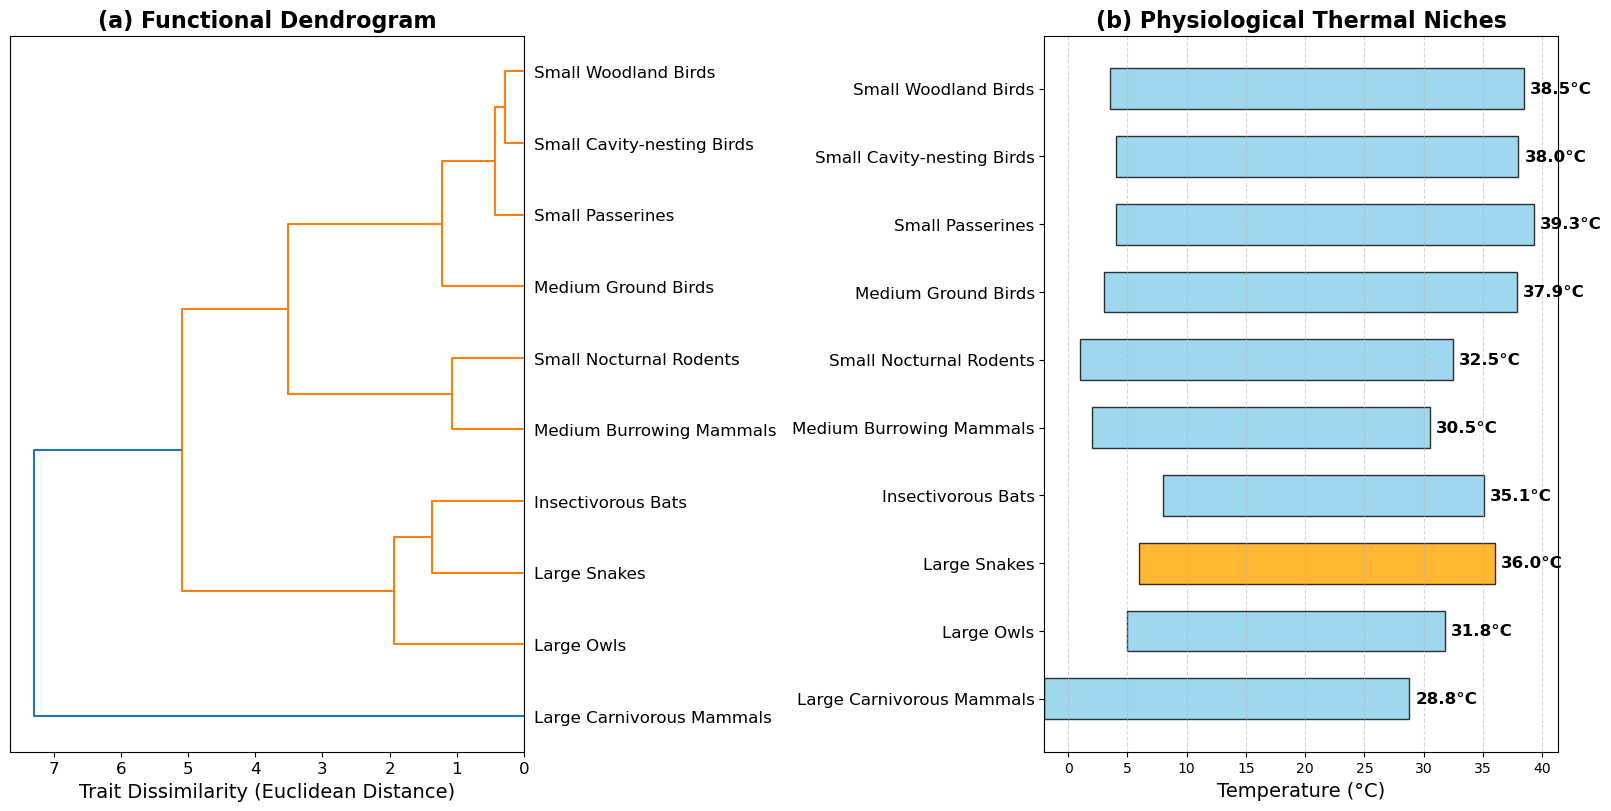

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

# 1. Recreate the Data (Same as before)
data = {
    'guild_name': [
        'Large Owls', 'Small Passerines', 'Medium Burrowing Mammals', 
        'Large Snakes', 'Medium Ground Birds', 'Large Carnivorous Mammals', 
        'Small Cavity-nesting Birds', 'Insectivorous Bats', 
        'Small Nocturnal Rodents', 'Small Woodland Birds'
    ],
    'tmax': [31.8, 39.3, 30.5, 36.0, 37.9, 28.8, 38.0, 35.1, 32.5, 38.5],
    'tmin': [5.0, 4.0, 2.0, 6.0, 3.0, -2.0, 4.0, 8.0, 1.0, 3.5],
    'body_mass_g': [1500, 25, 800, 2000, 400, 8000, 30, 15, 60, 18], 
    'max_longevity_yrs': [20, 5, 8, 25, 12, 15, 6, 20, 4, 7],
    'metabolic_rate_w': [4.5, 0.8, 3.2, 0.5, 2.1, 15.0, 0.9, 0.4, 1.1, 0.7]
}
df = pd.DataFrame(data).set_index('guild_name')

# 2. Setup the Composite Figure (1 Row, 2 Columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)

# --- PANEL A: DENDROGRAM ---
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
Z = linkage(df_scaled, method='ward')

dendrogram(
    Z,
    labels=df.index,
    ax=axes[0],
    orientation='left',  # Horizontal tree matches the horizontal bar chart better
    leaf_font_size=12,   # LARGE FONT
    color_threshold=0.7 * max(Z[:, 2])
)
axes[0].set_title('(a) Functional Dendrogram', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Trait Dissimilarity (Euclidean Distance)', fontsize=14)
axes[0].tick_params(axis='x', labelsize=12)

# --- PANEL B: THERMAL RANGES ---
# We sort the dataframe to match the visual order of the dendrogram leaves
# (This ensures the guild on the top left aligns with the guild on the top right)
dendro_idx = dendrogram(Z, no_plot=True)['leaves']
df_sorted = df.iloc[dendro_idx]

# Create Range Bars (Broken Barh plot)
y_pos = range(len(df_sorted))
height = 0.6

for i, (idx, row) in enumerate(df_sorted.iterrows()):
    # The bar spans from tmin to tmax
    width = row['tmax'] - row['tmin']
    left = row['tmin']
    
    # Color based on Endotherm vs Ectotherm (optional logic for visual pop)
    color = 'skyblue' if 'Snake' not in idx else 'orange'
    
    axes[1].barh(i * 10, width, height=6, left=left, align='center', 
                 color=color, alpha=0.8, edgecolor='black')

    # Add text labels for the Tmax values explicitly
    axes[1].text(row['tmax'] + 0.5, i * 10, f"{row['tmax']}°C", 
                 va='center', fontsize=12, fontweight='bold')

axes[1].set_yticks([i * 10 for i in range(len(df_sorted))])
axes[1].set_yticklabels(df_sorted.index, fontsize=12)
axes[1].set_xlabel('Temperature (°C)', fontsize=14)
axes[1].set_title('(b) Physiological Thermal Niches', fontsize=16, fontweight='bold')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

# Save
plt.savefig('../r_honours/outputs/figure_1_physiology.png', dpi=300)
plt.show()